## クラスタリング (教師なし学習)
ペンギンの種類のデータは伏せて，ペンギンの体の計測データのみを用いてクラスターに分けてみる

### ペンギンのデータ (penguins) の取得と前処理<br><span style="font-size:60%;">　(参照： https://github.com/allisonhorst/palmerpenguins/blob/main/README.md)</span>

<img src="https://raw.githubusercontent.com/allisonhorst/palmerpenguins/refs/heads/main/man/figures/culmen_depth.png" style="width:600px">

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
4,36.7,19.3,193.0,3450.0,Adelie
5,39.3,20.6,190.0,3650.0,Adelie
...,...,...,...,...,...
339,55.8,19.8,207.0,4000.0,Chinstrap
340,43.5,18.1,202.0,3400.0,Chinstrap
341,49.6,18.2,193.0,3775.0,Chinstrap
342,50.8,19.0,210.0,4100.0,Chinstrap


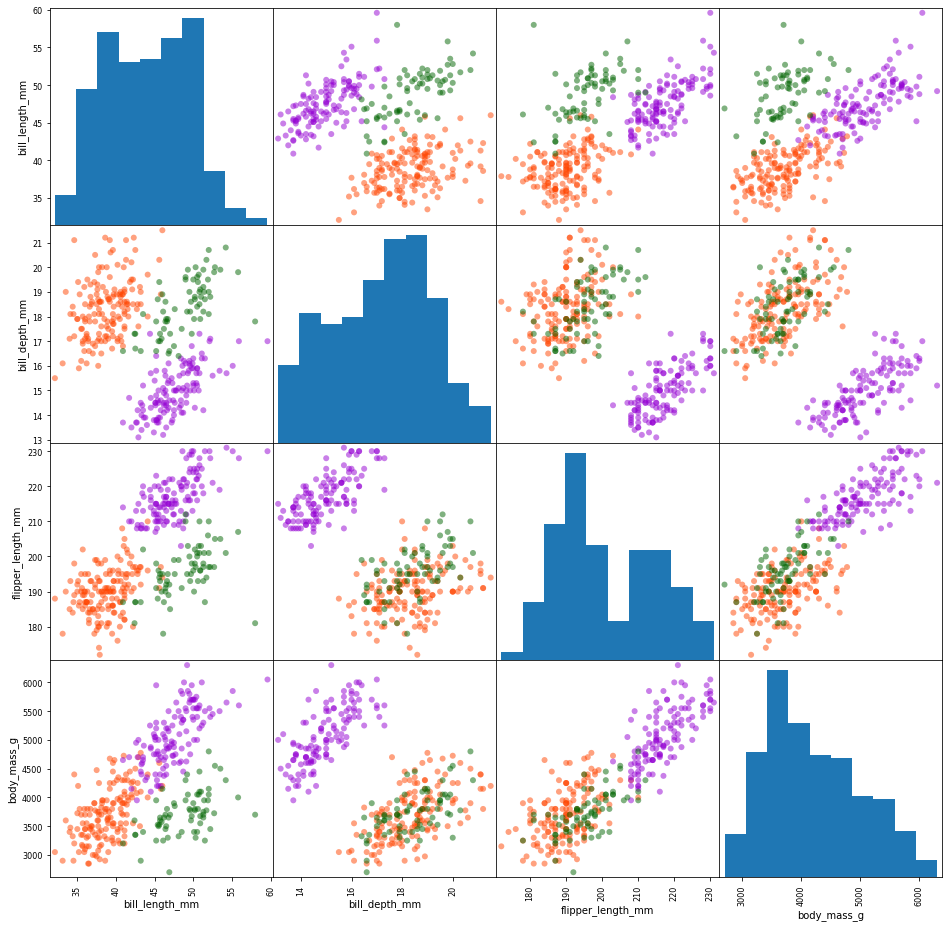

In [1]:
import requests     # Web上のデータを取得するライブラリをインポートする
import io           # 入出力用のライブラリをインポートする
import pandas as pd # pandas ライブラリを pd という名前でインポートする

# CSVファイルのURL
url_penguins = 'https://github.com/allisonhorst/palmerpenguins/raw/main/inst/extdata/penguins.csv'

# url_penguins のCSVファイルを取得して，データフレーム形式にして df_penguins に保存
df_penguins = pd.read_csv(io.BytesIO(requests.get(url_penguins).content))

# df_penguins に保存したデータフレームを表示
# display(df_penguins)

df_src = df_penguins[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g','species']].dropna()
display(df_src)

from pandas.plotting import scatter_matrix
# figsize でグラフを大きくし，alpha でドットの透明度を上げている
color_map = {'Adelie':'orangered', 'Chinstrap':'darkgreen', 'Gentoo':'darkviolet'}
_ = scatter_matrix( df_src[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']], 
                    c = df_src['species'].replace(color_map), 
                    marker = 'o',
                    figsize=(16, 16))

-   <span style="background-color: orangered">　</span> Adelie（アデリーペンギン）   
-   <span style="background-color: darkgreen">　</span> Chinstrap（ヒゲペンギン）   
-   <span style="background-color: darkviolet">　</span> Gentoo（ジェンツーペンギン）   

,bill_length_mm,flipper_length_mm,species
0,39.1,181.0,Adelie
1,39.5,186.0,Adelie
2,40.3,195.0,Adelie
4,36.7,193.0,Adelie
5,39.3,190.0,Adelie
...,...,...,...
339,55.8,207.0,Chinstrap
340,43.5,202.0,Chinstrap
341,49.6,193.0,Chinstrap
342,50.8,210.0,Chinstrap


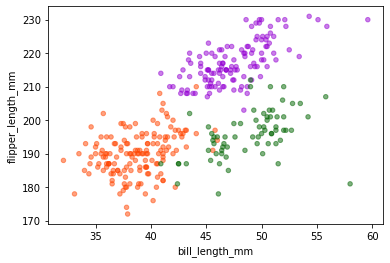

In [2]:
X_vars = ['bill_length_mm', 'flipper_length_mm']
y_var = 'species'

# 必要なデータを取り出し，欠損値 (NaN) を含む行を削除
df = df_src[X_vars + [y_var]]

X = df[X_vars]
y = df[y_var]

# データフレームの表示
display(df)

# 散布図の表示
_ = df.plot.scatter(
    x=X_vars[0], y=X_vars[1],
    c=df[y_var].replace(color_map),
    alpha=0.5,
)

-   <span style="background-color: orangered">　</span> Adelie（アデリーペンギン）   
-   <span style="background-color: darkgreen">　</span> Chinstrap（ヒゲペンギン）   
-   <span style="background-color: darkviolet">　</span> Gentoo（ジェンツーペンギン）   

### クラスタリング
ペンギンの種類 (`species`) のデータ抜きで，各ペンギンを3つのクラスターに分けてみる  
クラスタリングの手法にはさまざまなものがあるが，ここでは以下の3通りの方法でクラスタリングを行う．
-   k-平均 (k-means) 法
-   ウォード (Ward) 法
-   混合正規分布モデル (混合ガウスモデル; Gaussian mixture model; GMM) 

In [3]:
# クラスタリングの実行 (クラスターは番号で示される)

# KMeans の memory leak の回避
import os
os.environ['OMP_NUM_THREADS'] = '2'

# K-means 法
from sklearn.cluster import KMeans
kmeans = KMeans(3, random_state=0).fit(X)

# ウォード (Ward) 法
from sklearn.cluster import AgglomerativeClustering
ward = AgglomerativeClustering(3).fit(X)

# 混合正規分布モデル
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(3, random_state=0,).fit(X)

# 結果の列をデータに追加
df['kmeans'] = kmeans.predict(X)
df['ward'] = ward.labels_
df['gmm'] = gmm.predict(X)

# 表示
display(df)

C:\Users\miura\AppData\Local\Temp\ipykernel_28560\3938619071.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['kmeans'] = kmeans.predict(X)


,bill_length_mm,flipper_length_mm,species,kmeans,ward,gmm
0,39.1,181.0,Adelie,0,2,1
1,39.5,186.0,Adelie,0,2,1
2,40.3,195.0,Adelie,2,1,1
4,36.7,193.0,Adelie,0,1,1
5,39.3,190.0,Adelie,0,1,1
...,...,...,...,...,...,...
339,55.8,207.0,Chinstrap,1,1,2
340,43.5,202.0,Chinstrap,2,1,2
341,49.6,193.0,Chinstrap,2,1,2
342,50.8,210.0,Chinstrap,1,0,0


In [4]:
# クラスタ番号を名前に付け替え
df['kmeans'].replace({0:'Adelie', 1:'Gentoo', 2:'Chinstrap'}, inplace=True)
df['ward'].replace({2:'Adelie', 0:'Gentoo', 1:'Chinstrap'}, inplace=True)
df['gmm'].replace({1:'Adelie', 0:'Gentoo', 2:'Chinstrap'}, inplace=True)
display(df)

,bill_length_mm,flipper_length_mm,species,kmeans,ward,gmm
0,39.1,181.0,Adelie,Adelie,Adelie,Adelie
1,39.5,186.0,Adelie,Adelie,Adelie,Adelie
2,40.3,195.0,Adelie,Chinstrap,Chinstrap,Adelie
4,36.7,193.0,Adelie,Adelie,Chinstrap,Adelie
5,39.3,190.0,Adelie,Adelie,Chinstrap,Adelie
...,...,...,...,...,...,...
339,55.8,207.0,Chinstrap,Gentoo,Chinstrap,Chinstrap
340,43.5,202.0,Chinstrap,Chinstrap,Chinstrap,Chinstrap
341,49.6,193.0,Chinstrap,Chinstrap,Chinstrap,Chinstrap
342,50.8,210.0,Chinstrap,Gentoo,Gentoo,Gentoo


In [5]:
# 混同行列と正解率
from sklearn.metrics import confusion_matrix
print(confusion_matrix(df["species"], df["kmeans"]), end='\t')
print('kmeans 正解率:', round(100*len(df[df['species']==df['kmeans']])/len(df)), "%")
print(confusion_matrix(df["species"], df["ward"]), end='\t')
print('  ward 正解率:', round(100*len(df[df['species']==df['ward']])/len(df)), "%")
print(confusion_matrix(df["species"], df["gmm"]), end='\t')
print('   gmm 正解率:', round(100*len(df[df['species']==df['gmm']])/len(df)), "%")

[[111  38   2]
 [  9  54   5]
 [  0   1 122]]	kmeans 正解率: 84 %
[[ 52  97   2]
 [  2  62   4]
 [  0   1 122]]	  ward 正解率: 69 %
[[129  17   5]
 [  4  61   3]
 [  0   1 122]]	   gmm 正解率: 91 %


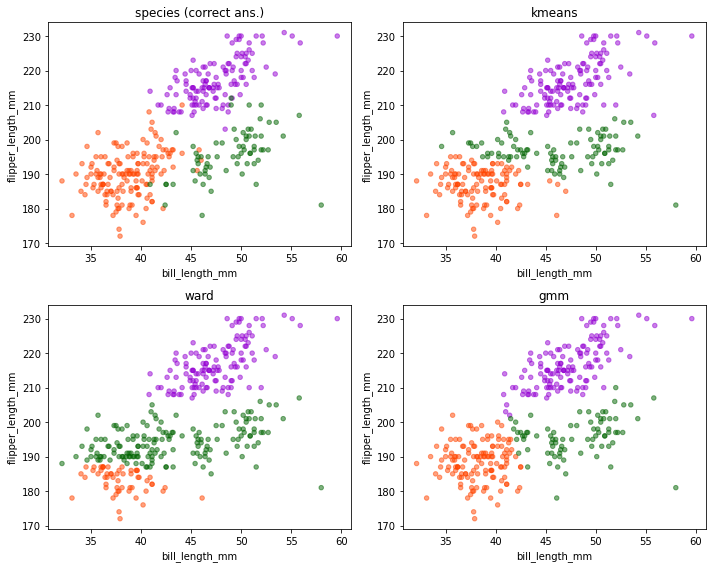

In [6]:
# 散布図の表示

# サブプロットを作成
import matplotlib.pyplot as plt
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

# 各サブプロットに散布図を描画
df.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df['species'].replace(color_map), alpha=0.5, title='species (correct ans.)',
    ax=axes[0, 0])
df.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df['kmeans'].replace(color_map), alpha=0.5, title='kmeans',
    ax=axes[0, 1])
df.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df['ward'].replace(color_map), alpha=0.5, title='ward',
    ax=axes[1, 0])
df.plot.scatter(
    x=X_vars[0], y=X_vars[1], c=df['gmm'].replace(color_map), alpha=0.5, title='gmm',
    ax=axes[1, 1])

plt.tight_layout()  # グラフ同士が重ならないように調整
plt.show()